# Collection of Exoplanet Interior models

This notebook describes how to load various grids of exoplanet interior structure models, and have ready-to-use interpolators on these models.

For each model, you need to download:
1. download the data grid
2. download the loader script
3. in the loader script, change the path of the folder where grids are located

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sweet_loader as sweet
import tang25_loader as t25

### Gas Dwarf: Tang 25 model

Download the radius grid at: https://github.com/an0wen/MARDIGRAS/blob/main/models/Tang2025.dat <br>
Download the max $f_\mathrm{env}$ grid at: https://github.com/an0wen/MARDIGRAS/blob/main/models/T24_grids/boil-off.csv ; this is the maximum initial envelope mass fraction $f_\mathrm{env}$ due to boil-off.<br>
(original data: https://zenodo.org/records/14847418 )<br>

#### Testing values

In [2]:
# Testing single value
top = 1 # radius at 20 mbar (clear atmosphere)
met = 1 # 1 times solar atmosphere and envelope
age = 1 # age in Gyr
teq = 400 # equilibrium temperature in K
mp_single = 1 # planet mass in Me
fenv = 1 # envelope mass fraction in %
single_radius = t25.radius_t25(top,met,age,teq,mp_single,fenv)
print(single_radius)
print()

# Testing array of masses
top = 1 # radius at 20 mbar (clear atmosphere)
met = 1 # 1 times solar atmosphere and envelope
age = 1 # age in Gyr
teq = 400 # equilibrium temperature in K
mp_array = np.linspace(1,10,5) # planet mass in Me
fenv = 1 # envelope mass fraction in %
radius_array = t25.radius_t25(top,met,age,teq,mp_array,fenv)
print(radius_array)
print()

Warning in 'radius_t25_grid', single value: fenv > maxfenv. maxfenv= 0.037 %
2.4744049634058003

[       nan 2.23264187 2.28830319 2.38529674 2.48510965]



#### Quick mass-radius plot

Quick plot with a loop on envelope mass fraction $f_\mathrm{env}$.

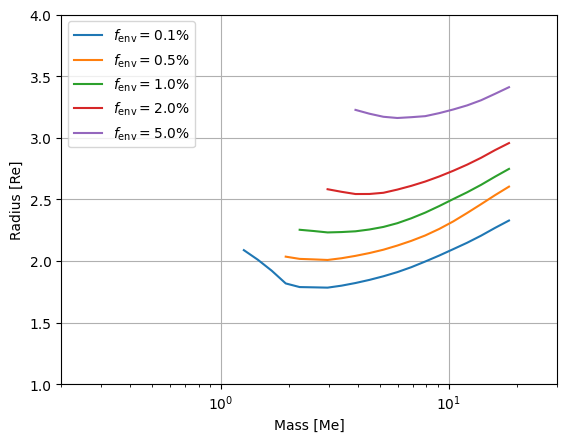

In [3]:
# Parameters common to all curves
top = 1 # radius at 20 mbar (clear atmosphere)
met = 1 # 1 times solar atmosphere and envelope
age = 1 # age in Gyr
teq = 400 # equilibrium temperature in K


mp_array = np.logspace(-1,2,50) # planet mass in Me

for fenv in np.array([0.1,0.5,1,2,5]):
    rp_array = t25.radius_t25(top,met,age,teq,mp_array,fenv)
    plt.plot(mp_array,rp_array,ls='-',label=rf"$f_\mathrm{{env}}={fenv}\%$")

# Figure options
plt.xscale("log")
plt.xlim(0.2,30)
plt.ylim(1, 4)
plt.xlabel('Mass [Me]')
plt.ylabel('Radius [Re]')
plt.legend()
plt.grid(visible=True,which='major', axis='both')
plt.show()

### Steam worlds: Aguichine 25 model

Download the radius grid at: https://github.com/an0wen/MARDIGRAS/blob/main/models/Aguichine2025_SWEET_all.dat <br>
(original data: https://zenodo.org/records/17811236 )<br>

#### Testing values

In [4]:
# Testing single value
top = 0 # radius at 20 mbar (clear atmosphere)
star = 1 # G-type host star
wmf = 10 # water mass fraction in %
teq = 400 # equilibrium temperature in K
mp_single = 1 # planet mass in Me
age = 1 # age in Gyr
single_radius = sweet.radius_swe(top,star,wmf,teq,mp_single,age)
print(single_radius)
print()

# Testing array of masses
top = 0 # radius at 20 mbar (clear atmosphere)
star = 1 # G-type host star
wmf = 10 # water mass fraction in %
teq = 400 # equilibrium temperature in K
mp_array = np.linspace(1,10,5) # planet mass in Me
age = 1 # age in Gyr
radius_array = sweet.radius_swe(top,star,wmf,teq,mp_array,age)
print(radius_array)
print()

1.248969037169205

[1.24896904 1.59447136 1.7984985  1.94878849 2.06731196]



#### Quick mass-radius plot

Quick plot with a loop on water mass fraction $x_\mathrm{H_2O}$.

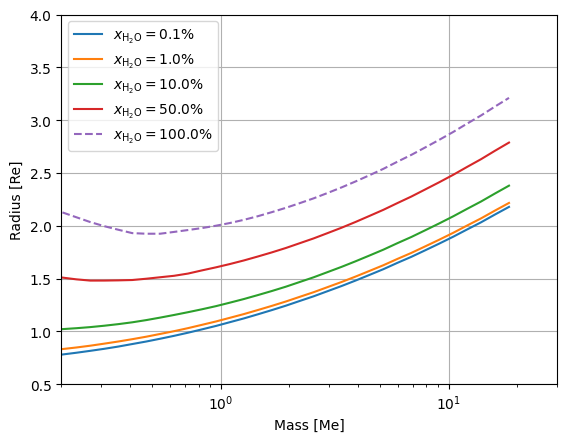

In [6]:
# Parameters common to all curves
top = 0 # radius at 20 mbar (clear atmosphere)
star = 1 # G-type host star
teq = 400 # equilibrium temperature in K
age = 1 # age in Gyr

mp_array = np.logspace(-1,2,50) # planet mass in Me

for wmf in np.array([0.1,1,10,50,100]):
    linestyle='-'
    if wmf==100: linestyle='--'
    rp_array = sweet.radius_swe(top,star,wmf,teq,mp_array,age)
    plt.plot(mp_array,rp_array,ls=linestyle,label=rf"$x_\mathrm{{H_2O}}={wmf}\%$")

# Figure options
plt.xscale("log")
plt.xlim(0.2,30)
plt.ylim(0.5, 4)
plt.xlabel('Mass [Me]')
plt.ylabel('Radius [Re]')
plt.legend()
plt.grid(visible=True,which='major', axis='both')
plt.show()